In [4]:
from IPython.display import Image
import xarray as xr
import numpy as np
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from matplotlib.colors import to_hex
import glob
import os
import pandas as pd


In [1]:
# Dictionnaire des modèles et de leurs chemins
cmip6_models = {
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Omon/tos/gn/v20200918/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Omon/tos/gn/v20200919/",
    #"EC-Earth3-CC": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-CC/piControl/r1i1p1f1/Omon/tos/gn/v20210416/",
    #"IPSL-CM6A-LR": "/g/data/oi10/replicas/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Omon/tos/gn/v20181123/",
    #"CIESM":  "/g/data/oi10/replicas/CMIP6/CMIP/THU/CIESM/piControl/r1i1p1f1/Omon/tos/gn/v20200220/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Omon/tos/gn/latest/",
    #"MCM-UA-1-0": "/g/data/oi10/replicas/CMIP6/CMIP/UA/MCM-UA-1-0/piControl/r1i1p1f1/Omon/tos/gn/v20190731/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Omon/tos/gn/v20190910/", 
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Omon/tos/gr/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Omon/tos/gr/v20190201/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Omon/tos/gn/v20191108/",
    #"NorESM2-LM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-LM/piControl/r1i1p1f1/Omon/tos/gn/v20210118/",
    #"NorCPM1": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorCPM1/piControl/r1i1p1f1/Omon/tos/gn/v20190914/",
    #"CESM2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Omon/tos/gn/v20190320/",
    #"CESM2-WACCM": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM/piControl/r1i1p1f1/Omon/tos/gn/v20190320/",
    #"CESM2-WACCM-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM-FV2/piControl/r1i1p1f1/Omon/tos/gn/v20191120/",
    #"CESM2-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-FV2/piControl/r1i1p1f1/Omon/tos/gn/v20191120/",
    #"GISS-E2-2-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-2-G/piControl/r1i1p1f1/Omon/tos/gn/v20191120/",    
    #"GISS-E2-1-H": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-H/piControl/r1i1p1f1/Omon/tos/gn/v20190410/",
    #"GISS-E2-1-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G/piControl/r1i1p1f1/Omon/tos/gn/v20180824/",
    #"GISS-E2-1-G-CC": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G-CC/piControl/r1i1p1f1/Omon/tos/gn/v20190815/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Omon/tos/gn/v20190904/",
    #"MPI-ESM1-2-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/piControl/r1i1p1f1/Omon/tos/gn/v20190710/",
    #"MPI-ESM1-2-HR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/piControl/r1i1p1f1/Omon/tos/gn/v20190710/",
    #"ICON-ESM-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/ICON-ESM-LR/piControl/r1i1p1f1/Omon/tos/gn/v20210215/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/tos/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Omon/tos/gn/v20190628/",
    #"MIROC6": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC6/piControl/r1i1p1f1/Omon/tos/gn/v20181212/",
    #"MIROC-ES2L": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC-ES2L/piControl/r1i1p1f2/Omon/tos/gn/v20190823/",
    #"CMCC-ESM2": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-ESM2/piControl/r1i1p1f1/Omon/tos/gn/v20210304/",
    #"CMCC-CM2-SR5": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/piControl/r1i1p1f1/Omon/tos/gn/v20200616/",
    #"CanESM5": "/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5/piControl/r1i1p1f1/Omon/tos/gn/v20190429/",
    #"CAMS-CSM1-0": "/g/data/oi10/replicas/CMIP6/CMIP/CAMS/CAMS-CSM1-0/piControl/r1i1p1f1/Omon/tos/gn/v20190729/",
    #"BCC-ESM1": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-ESM1/piControl/r1i1p1f1/Omon/tos/gn/v20181218/",
    #"BCC-CSM2-MR": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-CSM2-MR/piControl/r1i1p1f1/Omon/tos/gn/v20181015/",
    #"AWI-ESM-1-1-LR": "/g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-ESM-1-1-LR/piControl/r1i1p1f1/Omon/tos/gn/v20200212/",
}

# Dictionnaires pour stocker les résultats finaux
all_cmip_composites = {}
all_cmip_triples = {}
all_cmip_stds = {}
all_cmip_oni_objects = {}

In [2]:
def get_oni_noaa_style_piControl(da_weighted_mean):
    """Calcule l'ONI selon la méthodologie NOAA (30 ans glissants)."""
    anomalies = []
    time_coord = da_weighted_mean.time
    all_years = time_coord.dt.year.values
    unique_years = np.unique(all_years)
    first_yr, last_yr = unique_years[0], unique_years[-1]
    current_last_yr = first_yr
    all_spatial_composites = {} # Stockera [3_ans, lat, lon] pour chaque modèle

    for yr in range(first_yr + 15, last_yr - 14, 5):
        mask_period = (all_years >= yr) & (all_years <= yr + 4)
        mask_base = (all_years >= yr - 15) & (all_years <= yr + 14)
        data_slice = da_weighted_mean.isel(time=mask_period)
        base_slice = da_weighted_mean.isel(time=mask_base)
        if data_slice.size >= 60 and base_slice.size >= 360:
            anom = data_slice.groupby('time.month') - base_slice.groupby('time.month').mean(dim='time')
            anomalies.append(anom)
            current_last_yr = yr + 4

    if last_yr > current_last_yr:
        remainder_mask = (all_years > current_last_yr)
        base_end_mask = (all_years >= last_yr - 30) & (all_years <= last_yr)
        data_remainder = da_weighted_mean.isel(time=remainder_mask)
        base_end = da_weighted_mean.isel(time=base_end_mask)
        if data_remainder.size > 0 and base_end.size >= 360:
            anom_end = data_remainder.groupby('time.month') - base_end.groupby('time.month').mean(dim='time')
            anomalies.append(anom_end)
            
    if not anomalies: return None
    all_anom = xr.concat(anomalies, dim='time').sortby("time")
    all_anom = all_anom.sel(time=~all_anom.get_index("time").duplicated())
    return all_anom.rolling(time=3, center=True).mean().round(2)

def identify_triples_final(oni_da):
    """Identifie les Triple La Niña (seuil relatif 0.5*STD)."""
    std_val = float(oni_da.std())
    threshold = -0.5 * std_val
    is_lanina_month = (oni_da <= threshold)
    
    lanina_years = []
    all_years = np.unique(oni_da['time.year'])
    for yr in all_years[:-1]:
        mask_enso = ((oni_da['time.year'] == yr) & (oni_da['time.month'] >= 6)) | \
                    ((oni_da['time.year'] == yr + 1) & (oni_da['time.month'] <= 5))
        sub = is_lanina_month.where(mask_enso, drop=True)
        if len(sub) >= 12 and (sub.rolling(time=5).sum() >= 5).any():
            peak_months = [11, 12, 1, 2, 3]
            if is_lanina_month.where(mask_enso & oni_da['time.month'].isin(peak_months), drop=True).any():
                lanina_years.append(int(yr))
    
    triple_starts = []
    lanina_years = sorted(list(set(lanina_years)))
    for i in range(len(lanina_years) - 2):
        y0, y1, y2 = lanina_years[i], lanina_years[i+1], lanina_years[i+2]
        if (y1 == y0 + 1) and (y2 == y0 + 2):
            if (y0 - 1) not in lanina_years:
                triple_starts.append(y0)
    return triple_starts

In [5]:
# --- 1. INITIALISATION ---
all_spatial_composites = {} 
all_cmip_oni_objects = {}
all_cmip_stds = {}
all_cmip_triples = {}
all_cmip_composites = {}

print(f"Démarrage du traitement optimisé pour {len(cmip6_models)} modèles...")

for name, path in cmip6_models.items():
    clean_path = path.replace('*', '')
    if not os.path.exists(clean_path):
        print(f"Dossier introuvable pour {name}")
        continue

    print(f"\n--- Processing {name} ---")
    try:
        # On n'ouvre qu'une seule fois
        ds = xr.open_mfdataset(path + "*.nc", combine='by_coords', chunks={'time': 240}, use_cftime=True)
        
        # --- A. DÉTECTION COORDONNÉES ---
        lat_n = next((c for c in ['nav_lat', 'lat', 'latitude'] if c in ds.coords or c in ds.data_vars), None)
        lon_n = next((c for c in ['nav_lon', 'lon', 'longitude'] if c in ds.coords or c in ds.data_vars), None)
        
        if not lat_n or not lon_n:
            print(f"Coordonnées non trouvées.")
            continue

        # --- B. CALCUL ONI (Indice Temporel) ---
        lon_max = float(ds[lon_n].max())
        l1, l2 = (190, 240) if lon_max > 180 else (-170, -120)
        mask_nino = ((ds[lat_n] >= -5) & (ds[lat_n] <= 5) & (ds[lon_n] >= l1) & (ds[lon_n] <= l2)).compute()
        
        spatial_dims = [d for d in ds.tos.dims if d != 'time']
        if 'area' in ds.data_vars:
            weights = ds.area.where(mask_nino).fillna(0)
        else:
            weights = np.cos(np.deg2rad(ds[lat_n])).where(mask_nino).fillna(0)
            
        ts = ds.tos.where(mask_nino).weighted(weights).mean(dim=spatial_dims).compute()
        oni = get_oni_noaa_style_piControl(ts)
        
        if oni is not None:
            # Sauvegarde et stats de base
            all_cmip_oni_objects[name] = oni
            std_v = float(oni.std())
            all_cmip_stds[name] = std_v
            oni_std = oni / std_v
            
            # --- C. ANALYSE STATISTIQUE (Min, Max, % Increase) ---
            monthly_std = oni.groupby('time.month').std()
            min_std_val = float(monthly_std.min())
            max_std_val = float(monthly_std.max())
            increase_pct = (max_std_val / min_std_val - 1) * 100
            max_std_month = int(monthly_std.argmax()) + 1
            
            triples = identify_triples_final(oni)
            all_cmip_triples[name] = triples

            print(f"   Stats ONI:")
            print(f"    - STD globale: {std_v:.3f} °C | Min mensuelle: {min_std_val:.3f} °C")
            print(f"    - Max mensuelle: {max_std_val:.3f} °C (Mois {max_std_month})")
            print(f"    - Saisonnalité: +{increase_pct:.1f}% | Triples: {len(triples)}")

            # --- D. CALCUL SPATIAL (Uniquement si Triple trouvé) ---
            if len(triples) > 0:
                print(f"    -> Extraction spatiale...")
                mask_lat_map = ((ds[lat_n] >= -50) & (ds[lat_n] <= 50)).compute()
                ds_tos = ds.tos.where(mask_lat_map, drop=True)
                
                if ds_tos.mean() > 100: ds_tos = ds_tos - 273.15
                
                clim_ref = ds_tos.mean(dim='time').compute()
                
                event_composites = []
                for yr in triples:
                    year_maps = []
                    for offset in [0, 1, 2]:
                        target_yr = yr + offset
                        d1, d2 = f"{target_yr:04d}-12-01", f"{(target_yr+1):04d}-02-28"
                        try:
                            m = ds_tos.sel(time=slice(d1, d2)).mean(dim='time').compute()
                            year_maps.append(m - clim_ref)
                        except: continue
                    
                    if len(year_maps) == 3:
                        event_composites.append(xr.concat(year_maps, dim='year'))
                
                if event_composites:
                    all_spatial_composites[name] = xr.concat(event_composites, dim='event').mean(dim='event')

            # --- E. COMPOSITE TEMPOREL (36 mois) ---
            segments = []
            for yr in triples:
                try:
                    idx = int(np.where((oni_std['time.year'] == yr) & (oni_std['time.month'] == 6))[0][0])
                    seg = oni_std.isel(time=slice(idx, idx + 36))
                    if len(seg) == 36: segments.append(seg.values)
                except: continue
            all_cmip_composites[name] = np.mean(segments, axis=0) if segments else np.full(36, np.nan)

        ds.close() # Libère la mémoire
    except Exception as e:
        print(f"Erreur sur {name}: {e}")

print("\n--- TOUT EST TERMINÉ ---")

Démarrage du traitement optimisé pour 10 modèles...

--- Processing EC-Earth3 ---


KeyboardInterrupt: 

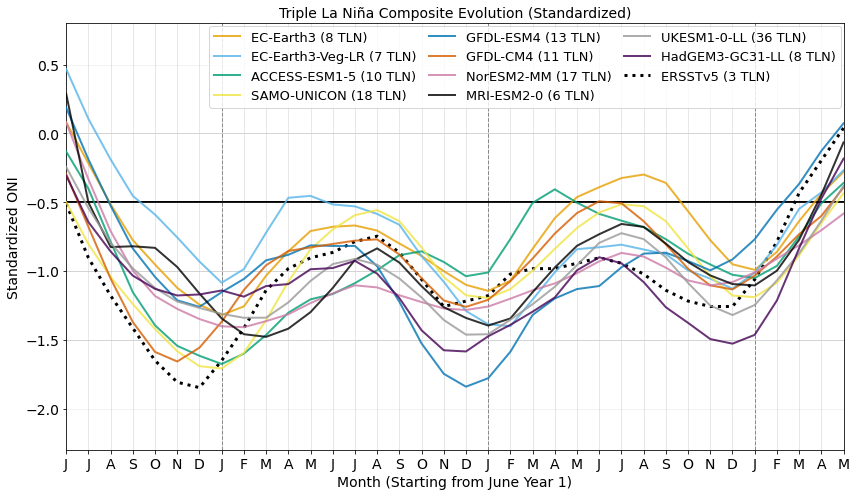

In [7]:
# --- CONFIGURATION DU PLOT MULTI-MODÈLES ---
fig = plt.figure(figsize=(12, 7))

# Définition des étiquettes de l'axe X (36 mois)
line_names = ['J','J','A','S','O','N','D', 'J','F','M','A','M',
              'J','J','A','S','O','N','D', 'J','F','M','A','M',
              'J','J','A','S','O','N','D', 'J','F','M','A','M']

# Palette Okabe-Ito for daltonian
okabe_ito_colors = [
    "#E69F00", # Orange (Saffron)
    "#56B4E9", # Sky Blue
    "#009E73", # Bluish Green
    "#F0E442", # Yellow
    "#0072B2", # Blue
    "#D55E00", # Vermillion (Orange-Red)
    "#CC79A7", # Reddish Purple
    "#000000", # Black
    "#999999", # Grey
    "#440154",
    "#f781bf", # Dark Purple (type Viridis) pour la 10ème
]

custom_ticks = np.arange(len(line_names))
plt.xticks(custom_ticks, line_names, fontsize=14)

# --- Lignes de structure verticales ---

# 1. Lignes pour CHAQUE MOIS (très fines)
for month_index in range(36):
    plt.axvline(x=month_index, color='grey', linestyle='-', linewidth=0.6, alpha=0.3, zorder=0)

# 2. Lignes pour les DÉCEMBRES (plus marquées pour séparer les années)
for dec_index in [7, 19, 31]:
    plt.axvline(x=dec_index, color='black', linestyle='--', linewidth=1.0, alpha=0.4, zorder=0)

# Lignes de seuils horizontales (Standardisées)
for y_value in [0, -0.5, -1, -1.5]:
    plt.axhline(y=y_value, color='lightgrey', linewidth=0.8, zorder=0)

# --- TRACÉ DES COMPOSITES ---

# Utilisation d'une colormap pour différencier les 9 modèles
for i, (name, composite) in enumerate(all_cmip_composites.items()):
    # On récupère le nombre d'événements pour la légende
    
    n_events = len(all_cmip_triples.get(name, []))
    
    # On ne trace que si le composite n'est pas vide (contient des données)
    if not np.all(np.isnan(composite)):
        plt.plot(composite, 
                 label=f'{name} ({n_events} TLN)', 
                 color = okabe_ito_colors[i % len(okabe_ito_colors)], 
                 linewidth=2, 
                 alpha=0.8,
                 zorder=5)
    else:
        print(f"Info: 0 events for {name}")
plt.axhline(y=-0.5, color='black', linewidth=2.0, linestyle='-', zorder=0)

# On recharge les données
ersst_loaded = np.load('/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/ersst_data_TLN_ERSST.npy')

# On peut maintenant l'ajouter à n'importe quel plot
plt.plot(ersst_loaded, label='ERSSTv5 (3 TLN)', color='black', linewidth=3, linestyle=':')

# --- ESTHÉTIQUE FINALE ---
plt.title('Triple La Niña Composite Evolution (Standardized)', fontsize=14)
plt.xlabel('Month (Starting from June Year 1)', fontsize=14)
plt.ylabel('Standardized ONI', fontsize=14)

# Légende à l'extérieur si elle est trop grosse, ou en bas à gauche
plt.legend(
    frameon=True, 
    loc='upper right',           # On change souvent loc en 'upper left' quand on sort du cadre
    bbox_to_anchor=(1.005, 1.01),   # Positionne la légende à droite du graphique
    fontsize=13,                # Légèrement réduit pour 2 colonnes
    ncol=3,                     # 2 columns
    columnspacing=1.0           # Espace entre les deux colonnes
)

plt.grid(True, axis='y', alpha=0.2)
plt.yticks(fontsize=14)
plt.xlim(0, 35)
plt.ylim(-2.3, 0.8) # Adapté pour voir les variations au-dessus de 0

plt.tight_layout()

# --- SAUVEGARDE ---
save_path_all = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/sp_CMIP6_Triple_LN_36mth.png'
fig.savefig(save_path_all, 
            bbox_inches='tight', 
            dpi=600, 
            facecolor='white', 
            edgecolor='none')

plt.show()

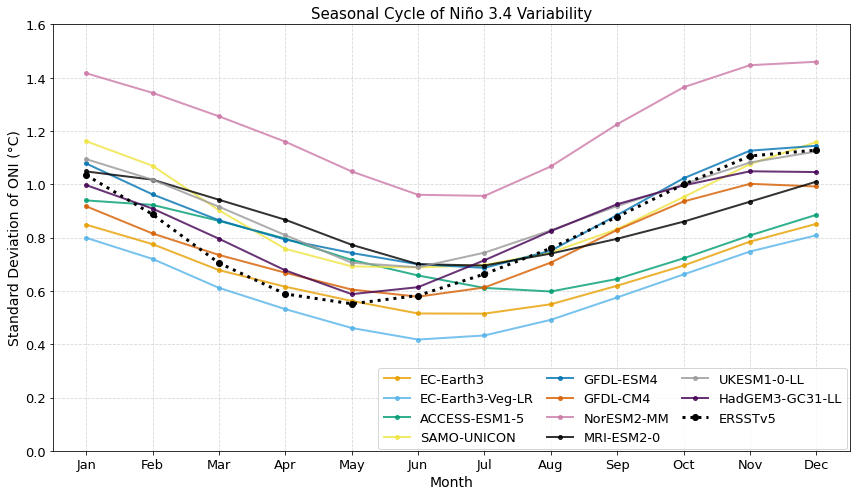

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT DES DONNÉES ---
all_model_seasonal_std = {}

# Chargement ERSST (en fichiers séparés pour éviter l'erreur de version)
try:
    ersst_cycle = np.load('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/ersst_cycle.npy')
    ersst_global = np.load('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/ersst_global.npy')[0]
    ersst_label = f"ERSSTv5"
except:
    print("Fichiers ERSST introuvables, vérifiez les chemins.")

# Calcul pour les modèles CMIP
for name, oni_series in all_cmip_oni_objects.items():
    # .values pour s'assurer qu'on a un array numpy propre
    monthly_std = oni_series.groupby('time.month').std().values
    all_model_seasonal_std[name] = monthly_std

# --- 2. PLOTTING ---
plt.figure(figsize=(12, 7)) # Un peu plus large pour la légende

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Palette de couleurs
colors = ["#E69F00", # Orange (Saffron)
    "#56B4E9", # Sky Blue
    "#009E73", # Bluish Green
    "#F0E442", # Yellow
    "#0072B2", # Blue
    "#D55E00", # Vermillion (Orange-Red)
    "#CC79A7", # Reddish Purple
    "#000000", # Black
    "#999999", # Grey
    "#440154",
    "#f781bf", # Dark Purple (type Viridis) pour la 10ème
]

# 2. Tracer les modèles CMIP
for i, (name, std_12pts) in enumerate(all_model_seasonal_std.items()):
    plt.plot(range(1, 13), std_12pts, 
             label=name, 
             color=colors[i % len(colors)], 
             linewidth=2, 
             marker='o', 
             markersize=4,
             alpha=0.8)
    
# 1. Tracer ERSST en premier (Pointillé noir)
plt.plot(range(1, 13), ersst_cycle, 
         label=ersst_label, 
         color='black', 
         marker='o', 
         markersize=6, 
         linestyle=':', 
         linewidth=3, 
         zorder=10) # Toujours au premier plan
# Cosmétique
plt.title('Seasonal Cycle of Niño 3.4 Variability', fontsize=15)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Standard Deviation of ONI (°C)', fontsize=14)

plt.xticks(range(1, 13), month_names, fontsize=13)
plt.yticks(fontsize=13)

# Légende 
plt.legend(
    frameon=True, 
    loc='lower right',           # On change souvent loc en 'upper left' quand on sort du cadre
    bbox_to_anchor=(1.005, -0.012),   # Positionne la légende à droite du graphique
    fontsize=13,                # Légèrement réduit pour 2 colonnes
    ncol=3,                     # 2 columns
    columnspacing=1.0           # Espace entre les deux colonnes
)

plt.savefig('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/sp_Monthly_STD_Comparison_CMIP6.png', bbox_inches='tight', dpi=300)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0.5, 12.5)
plt.ylim(0, 1.6)

plt.tight_layout()
plt.show()

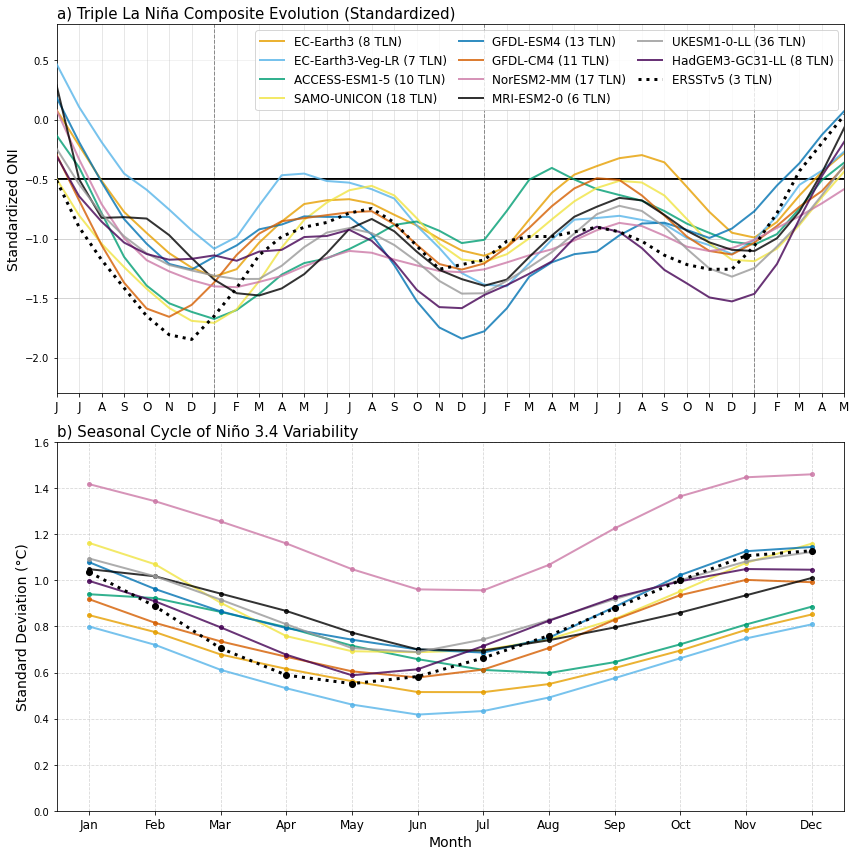

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PRÉPARATION DE LA FIGURE (2 lignes, 1 colonne) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
fig.subplots_adjust(hspace=0.4) # Espace entre les deux graphiques

# Palette Okabe-Ito harmonisée pour les deux plots
okabe_ito_colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", 
                    "#D55E00", "#CC79A7", "#000000", "#999999", "#440154", "#f781bf"]

# =================================================================
# PARTIE DU HAUT : TRIPLE LA NIÑA COMPOSITE (36 MOIS)
# =================================================================
line_names_36 = ['J','J','A','S','O','N','D', 'J','F','M','A','M',
                 'J','J','A','S','O','N','D', 'J','F','M','A','M',
                 'J','J','A','S','O','N','D', 'J','F','M','A','M']

# Structure verticale
for m_idx in range(36):
    ax1.axvline(x=m_idx, color='grey', linestyle='-', linewidth=0.6, alpha=0.3, zorder=0)
for dec_idx in [7, 19, 31]:
    ax1.axvline(x=dec_idx, color='black', linestyle='--', linewidth=1.0, alpha=0.4, zorder=0)
for y_val in [0, -0.5, -1, -1.5]:
    ax1.axhline(y=y_val, color='lightgrey', linewidth=0.8, zorder=0)

# Tracé CMIP6
for i, (name, composite) in enumerate(all_cmip_composites.items()):
    n_events = len(all_cmip_triples.get(name, []))
    if not np.all(np.isnan(composite)):
        ax1.plot(composite, label=f'{name} ({n_events} TLN)', 
                 color=okabe_ito_colors[i % len(okabe_ito_colors)], linewidth=2, alpha=0.8, zorder=5)

# Tracé ERSSTv5 (chargé précédemment)
ax1.plot(ersst_loaded, label='ERSSTv5 (3 TLN)', color='black', linewidth=3, linestyle=':', zorder=10)
ax1.axhline(y=-0.5, color='black', linewidth=2.0, linestyle='-', zorder=0)

# Cosmétique AX1
ax1.set_title('a) Triple La Niña Composite Evolution (Standardized)', fontsize=15, loc='left')
ax1.set_ylabel('Standardized ONI', fontsize=14)
ax1.set_xticks(np.arange(len(line_names_36)))
ax1.set_xticklabels(line_names_36, fontsize=12)
ax1.set_xlim(0, 35)
ax1.set_ylim(-2.3, 0.8)
ax1.legend(frameon=True, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=12, ncol=3, columnspacing=1.0)
ax1.grid(True, axis='y', alpha=0.2)

# =================================================================
# PARTIE DU BAS : VARIABILITÉ SAISONNIÈRE (STD)
# =================================================================
month_names_12 = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Tracé CMIP6
for i, (name, std_12pts) in enumerate(all_model_seasonal_std.items()):
    ax2.plot(range(1, 13), std_12pts, label=name, 
             color=okabe_ito_colors[i % len(okabe_ito_colors)], linewidth=2, marker='o', markersize=4, alpha=0.8)

# Tracé ERSSTv5
ax2.plot(range(1, 13), ersst_cycle, label='ERSSTv5', color='black', 
         marker='o', markersize=6, linestyle=':', linewidth=3, zorder=10)

# Cosmétique AX2
ax2.set_title('b) Seasonal Cycle of Niño 3.4 Variability', fontsize=15, loc='left')
ax2.set_xlabel('Month', fontsize=14)
ax2.set_ylabel('Standard Deviation (°C)', fontsize=14)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names_12, fontsize=12)
ax2.set_xlim(0.5, 12.5)
ax2.set_ylim(0, 1.6)
ax2.grid(True, linestyle='--', alpha=0.5)
#ax2.legend(frameon=True, loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=12, ncol=4, columnspacing=1.0)

# --- SAUVEGARDE FINALE ---
plt.tight_layout()
save_path_combined = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/combined_TLN_Variability.png'
plt.savefig(save_path_combined, bbox_inches='tight', dpi=600, facecolor='white')
plt.show()

## Triple La Nina exportation for pr and mrso analysis

In [ ]:
# On transforme le dictionnaire des triples en une liste plate
data_for_export = []
for model_name, years in all_cmip_triples.items():
    for yr in years:
        data_for_export.append({"model": model_name, "triple_start_year": yr})

# Création d'un DataFrame
df_triples = pd.DataFrame(data_for_export)

# Sauvegarde en CSV
csv_path = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_catalog_sp.csv'
df_triples.to_csv(csv_path, index=False)

In [ ]:
import xarray as xr
import numpy as np

# Supposons que tu as déjà 'all_cmip_composites' (tes moyennes de 36 mois)
# On va créer un DataArray à partir de ce dictionnaire
models = list(all_cmip_composites.keys())
data_matrix = np.array([all_cmip_composites[m] for m in models])

# Création de l'objet Xarray
ds_out = xr.Dataset(
    data_vars={
        "oni_composite": (("model", "month_index"), data_matrix),
    },
    coords={
        "model": models,
        "month_index": np.arange(36),
    },
    attrs={
        "description": "Composites ONI de 36 mois pour Triple La Niña",
        "units": "Standardized Anomalies (sigma)",
        "creator": "PhD Analysis"
    }
)

# Sauvegarde en NetCDF
nc_path = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_composites_ONI_sp.nc'
ds_out.to_netcdf(nc_path)
print(f"Fichier NetCDF sauvegardé : {nc_path}")

Fichier NetCDF sauvegardé : /g/data/m35/qr1706/PhD-1_CMIP_analysis/csv/triple_lanina_composites_ONI_sp.nc
